In [4]:
import pandas as pd

In [5]:
df_raw = pd.read_stata('data/Data_Exp1234_clean.dta')

In [6]:
df_raw.ab_nominal.unique()

array([20.  ,  1.  ,  0.1 ,  8.  ,  0.05, 10.  ])

In [7]:
df_raw

,confidence,correct,true_shock,ab_nominal,rt,endowment,concentration,anxiety,totalmistakes,age,...,stake,stake_nominal,difficult,aligned,wishful,confusioncontrol,never_felt_deceived,bai,dpessimism,idtreatmentblock
0,0.60,1,1,20.00,4349.0,NaN,NaN,NaN,NaN,21.0,...,NaN,NaN,0.0,1.0,22.916664,NaN,5.0,1.190476,NaN,10.0
1,0.60,1,0,20.00,3796.0,NaN,NaN,NaN,NaN,21.0,...,NaN,NaN,1.0,0.0,22.916664,NaN,5.0,1.190476,NaN,10.0
2,0.65,0,0,20.00,2201.0,NaN,NaN,NaN,NaN,21.0,...,NaN,NaN,1.0,1.0,22.916664,NaN,5.0,1.190476,NaN,10.0
3,0.80,1,0,20.00,2945.0,NaN,NaN,NaN,NaN,21.0,...,NaN,NaN,0.0,0.0,22.916664,NaN,5.0,1.190476,NaN,10.0
4,0.70,0,0,20.00,3405.0,NaN,NaN,NaN,NaN,21.0,...,NaN,NaN,2.0,0.0,22.916664,NaN,5.0,1.190476,NaN,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97628,NaN,1,1,0.05,14534.5,0.0,4.0,0.0,3.0,48.0,...,0.0,0.0,0.0,NaN,-3.260872,0.0,4.0,1.857143,6.0,101133.0
97629,NaN,1,0,0.05,15099.3,0.0,4.0,0.0,3.0,48.0,...,0.0,0.0,0.0,NaN,-3.260872,0.0,4.0,1.857143,6.0,101133.0
97630,NaN,1,1,0.05,1715.6,0.0,4.0,0.0,3.0,48.0,...,0.0,0.0,2.0,NaN,-3.260872,0.0,4.0,1.857143,6.0,101133.0
97631,NaN,0,1,0.05,2599.6,0.0,4.0,0.0,3.0,48.0,...,0.0,0.0,3.0,NaN,-3.260872,0.0,4.0,1.857143,6.0,101133.0


In [8]:
import sqlite3
import pandas as pd

db_path = "hssm_sim_fits_th.sqlite"
with sqlite3.connect(db_path) as conn:
    # Get all tables that exist
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';",
        conn
    )
    print("Tables in database:")
    print(tables)

Tables in database:
         name
0   ddm_mod_v
1  ddm_mod_th
2    ddm_pure


In [9]:
db_paths = [
    "hssm_sim_fits_th.sqlite",
    "hssm_sim_fits_v.sqlite",
    "hssm_sim_fits_pure.sqlite"]

for db_path in db_paths:
    with sqlite3.connect(db_path) as conn:
        print(f"Exploring database: {db_path}")
        df_ddm_pure = pd.read_sql("SELECT * FROM ddm_pure", conn)
        print("Amount of participants on table: ")
        print(df_ddm_pure.participant_id.nunique())
        df_ddm_mod_th = pd.read_sql("SELECT * FROM ddm_mod_th", conn)
        print("Amount of participants on table: ")
        print(df_ddm_mod_th.participant_id.nunique())
        df_ddm_mod_v = pd.read_sql("SELECT * FROM ddm_mod_v", conn)
        print("Amount of participants on table: ")
        print(df_ddm_mod_v.participant_id.nunique())

Exploring database: hssm_sim_fits_th.sqlite
Amount of participants on table: 
343
Amount of participants on table: 
343
Amount of participants on table: 
343
Exploring database: hssm_sim_fits_v.sqlite
Amount of participants on table: 
343
Amount of participants on table: 
343
Amount of participants on table: 
343
Exploring database: hssm_sim_fits_pure.sqlite
Amount of participants on table: 
342
Amount of participants on table: 
342
Amount of participants on table: 
342


# analysis of betas

In [24]:
import matplotlib.pyplot as plt

In [11]:
import sqlite3
import pandas as pd

db_path = "hssm_fits.sqlite"
with sqlite3.connect(db_path) as conn:
    # Get all tables that exist
    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';",
        conn
    )
    print("Tables in database:")
    print(tables)

Tables in database:
         name
0  ddm_mod_th
1   ddm_mod_v
2    ddm_pure


In [25]:
with sqlite3.connect(db_path) as conn:
    # Get all tables that exist
    df_v = pd.read_sql(
        "SELECT * FROM ddm_mod_v WHERE param = 'v_Intercept' OR param = 'v_X'",
        conn
    )

In [29]:
df_v

,param,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat,participant_id,timestamp
0,v_Intercept,0.478,0.148,0.194,0.746,0.006,0.004,672.0,625.0,1.00,708,2026-01-30T17:44:28.423188
1,v_X,0.084,0.124,-0.172,0.284,0.005,0.004,655.0,596.0,1.00,708,2026-01-30T17:44:28.423188
2,v_Intercept,0.166,0.132,-0.061,0.415,0.006,0.004,525.0,600.0,1.01,709,2026-01-30T17:45:05.308806
3,v_X,0.086,0.116,-0.122,0.302,0.004,0.003,805.0,714.0,1.00,709,2026-01-30T17:45:05.308806
4,v_Intercept,0.623,0.131,0.384,0.887,0.016,0.011,76.0,91.0,1.06,710,2026-01-30T17:47:56.675959
...,...,...,...,...,...,...,...,...,...,...,...,...
681,v_X,-0.022,0.127,-0.266,0.214,0.005,0.004,656.0,642.0,1.01,1111,2026-02-01T23:55:27.017683
682,v_Intercept,0.434,0.144,0.163,0.701,0.007,0.005,388.0,643.0,1.01,1112,2026-02-01T23:55:59.139893
683,v_X,-0.037,0.137,-0.320,0.193,0.006,0.005,613.0,399.0,1.01,1112,2026-02-01T23:55:59.139893
684,v_Intercept,0.749,0.142,0.445,0.949,0.034,0.024,18.0,280.0,1.13,1113,2026-02-02T00:01:25.368211


In [28]:
df_v[df_v.param == 'v_X']['mean'].mean()

-0.006985422740524781

In [30]:
df_v[df_v.param == 'v_X']['sd'].mean()

0.12116034985422741

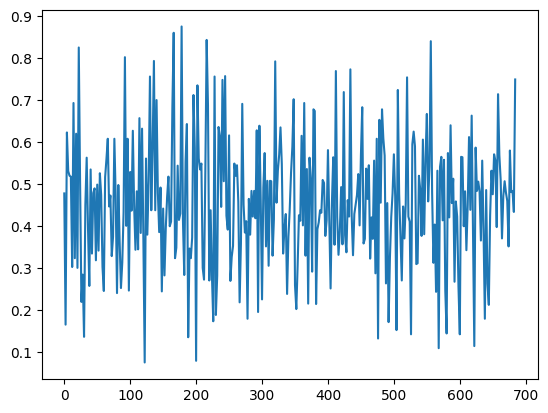

In [63]:
plt.plot(df_v[df_v.param == 'v_Intercept']['mean'])

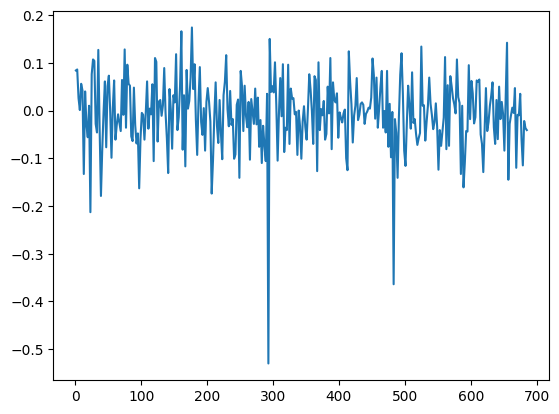

In [31]:
plt.plot(df_v[df_v.param == 'v_X']['mean'])

In [36]:
with sqlite3.connect(db_path) as conn:
    # Get all tables that exist
    df_th = pd.read_sql(
        "SELECT * FROM ddm_mod_th WHERE param = 'a_Intercept' OR param = 'a_X'",
        conn
    )

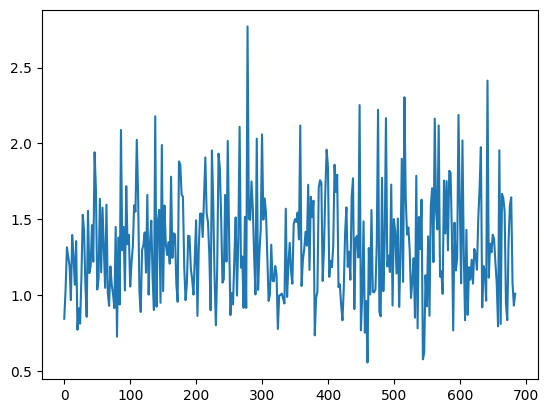

In [42]:
plt.plot(df_th[df_th.param == 'a_Intercept']['mean'])

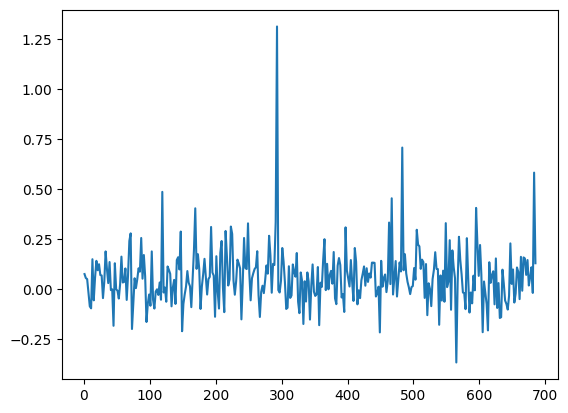

In [41]:
plt.plot(df_th[df_th.param == 'a_X']['mean'])

In [38]:
df_th[df_th.param == 'a_X']['mean'].mean()

0.06129446064139941

In [40]:
df_th[df_th.param == 'a_X']['sd'].mean()

0.12251895043731778

cgpt

In [45]:
df_vx = df_v[df_v.param == 'v_X'].copy()
df_vx['z'] = df_vx['mean'] / df_vx['sd']


In [54]:
df_th = pd.read_sql(
    "SELECT * FROM ddm_mod_th WHERE param = 'a_X'",
    conn
)

df_th['z'] = df_th['mean'] / df_th['sd']


In [55]:
df_vx['z'].mean(), df_th['z'].mean()


(-0.0654359407584957, 0.47076931148894474)

In [56]:
df_vx['z'].abs().mean(), df_th['z'].abs().mean()


(0.45800179132275776, 0.8577274332214442)

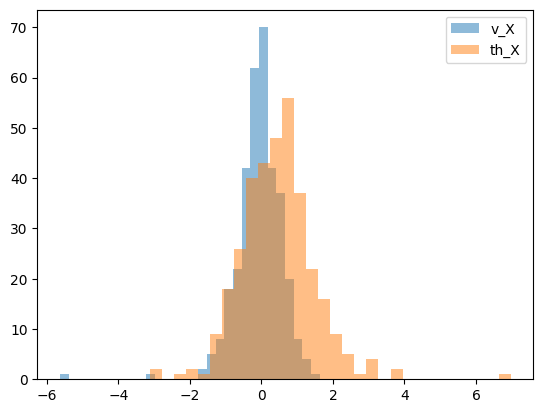

In [60]:
plt.hist(df_vx['z'], bins=30, alpha=0.5, label='v_X')
plt.hist(df_th['z'], bins=30, alpha=0.5, label='th_X')
plt.legend()


In [61]:
R = df_th['z'].abs().mean() / df_vx['z'].abs().mean()

In [62]:
R

1.87275999673328

We compared the standardized weights of X in separate drift and threshold models. X had a substantially larger effect in the threshold model (R = 1.87), suggesting that, within the respective models, X primarily modulates the threshold parameter rather than the drift rate